In [1]:
#load packages
import numpy as np
import sys
import os 
import sys
import pandas as pd 
import seaborn as sns
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

sys.path.append(os.path.abspath(".."))
import os
os.chdir(os.path.expanduser(r"~/Documents/CHL8010/CPCSSN-Group-Project/notebooks"))
import functions.wrangling as wrg
import functions.missing_labs as ml
import functions.eda_model as em

In [2]:
# load dataset
df = ml.load_data("bd_labs_after_cleaned_all.csv")

Loaded dataset with shape: (1196, 11)


## In the EDA.ipynb file, we provide preliminary statistical characteristics of the lab tests. In our dataset, the 'PerformedDate' column represents the specific date when each patient underwent a lab test after being diagnosed with bipolar disorder. We aim to analyze the trend of their lab test results over time.

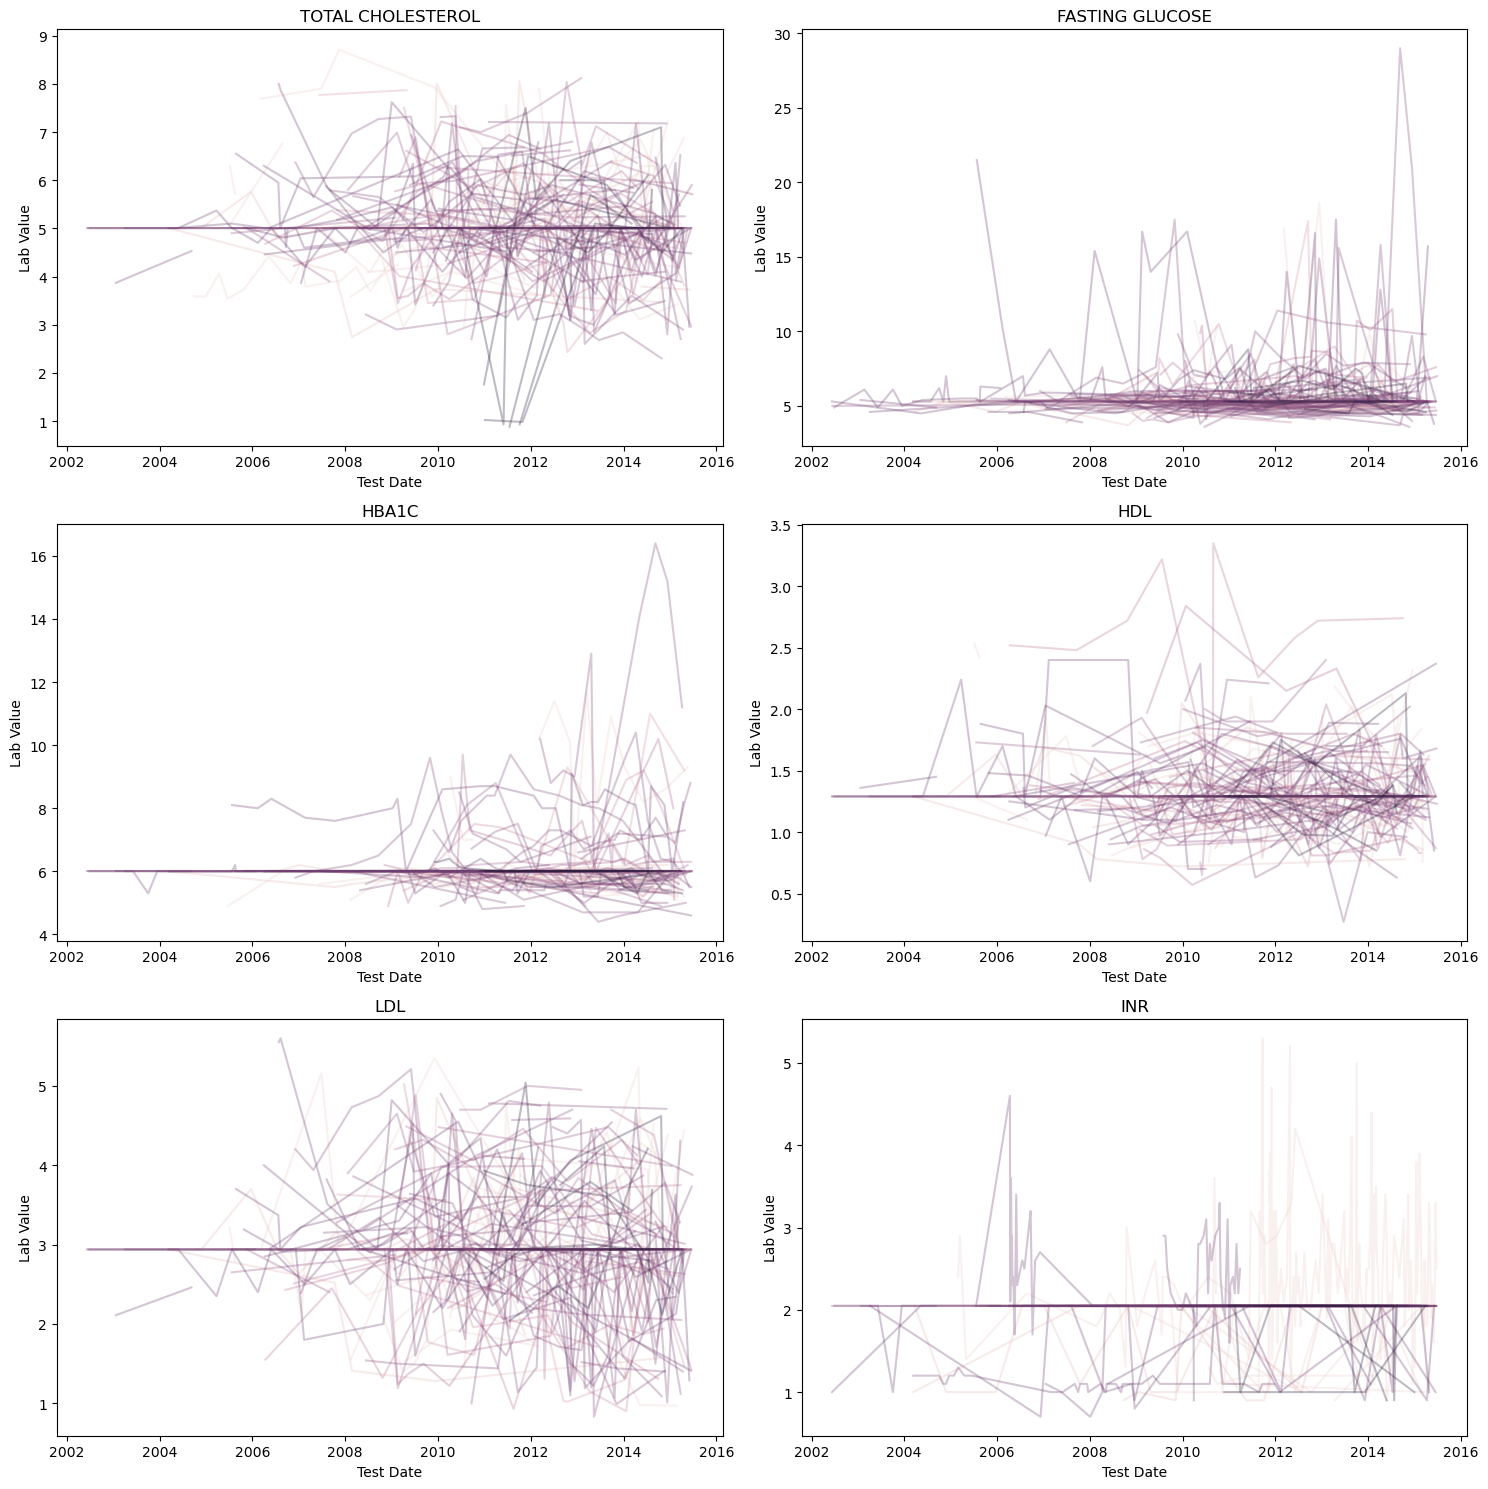

In [3]:
em.plot_trends(
    data=df,
    variables=['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C', 
            'HDL', 'LDL', 'INR'],
    date='PerformedDate',
    hue='Patient_ID',
    xlabel='Test Date',
    ylabel='Lab Value'
)

## After generating the trajectory plots using actual dates, we found the patterns to be quite messy and difficult to interpret. To address this, we standardized the 'PerformedDate' by converting it to a 'VisitOrder' variable—grouping by patient and ordering their lab test records chronologically.

In [4]:
df = df.sort_values(['Patient_ID', 'PerformedDate'])
df['VisitOrder'] = df.groupby('Patient_ID').cumcount() + 1

## How many individuals are present at each visit?

Descriptive statistics of total visits per patient:
count    214.000000
mean       5.588785
std       13.876689
min        1.000000
25%        1.000000
50%        2.000000
75%        6.000000
max      189.000000
Name: TotalVisits, dtype: float64

Frequency distribution of total visits:
TotalVisits
1      75
2      34
3      18
4      17
5      11
6       8
7      11
8       3
9       6
10      6
11      8
12      3
13      1
14      1
16      2
19      1
20      1
25      2
28      3
33      1
35      1
189     1
Name: count, dtype: int64


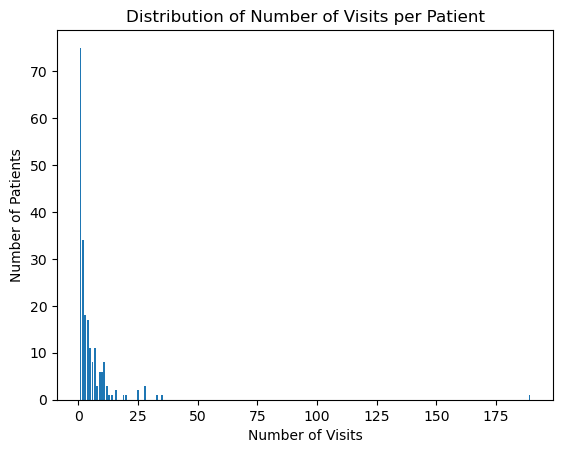

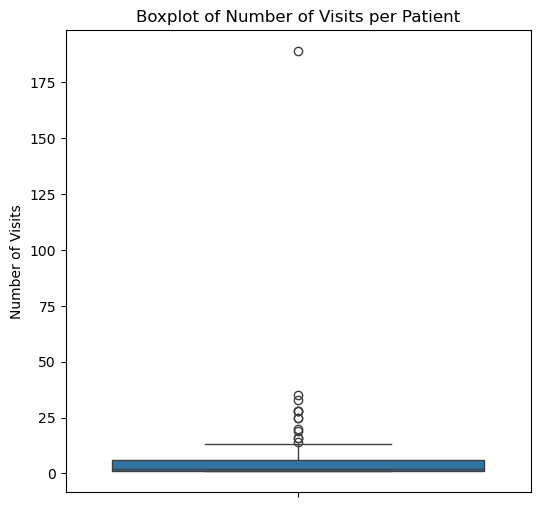

In [5]:
# Calculate the total number of visits per patient
visit_counts = df.groupby('Patient_ID')['VisitOrder'].max().reset_index(name='TotalVisits')

# Descriptive statistics
print("Descriptive statistics of total visits per patient:")
print(visit_counts['TotalVisits'].describe())

# Frequency distribution
print("\nFrequency distribution of total visits:")
print(visit_counts['TotalVisits'].value_counts().sort_index())

# Histogram of Number of Visits per Patient
plt.hist(visit_counts['TotalVisits'], bins=range(1, visit_counts['TotalVisits'].max()+2), align='left', rwidth=0.8)
plt.xlabel('Number of Visits')
plt.ylabel('Number of Patients')
plt.title('Distribution of Number of Visits per Patient')
plt.show()

# Boxplot of Number of Visits per Patient
plt.figure(figsize=(6, 6))
sns.boxplot(y=visit_counts['TotalVisits'])
plt.title('Boxplot of Number of Visits per Patient')
plt.ylabel('Number of Visits')
plt.show()

## On average, patients have 5 visits. There are 8 patients who each had 11 visits.

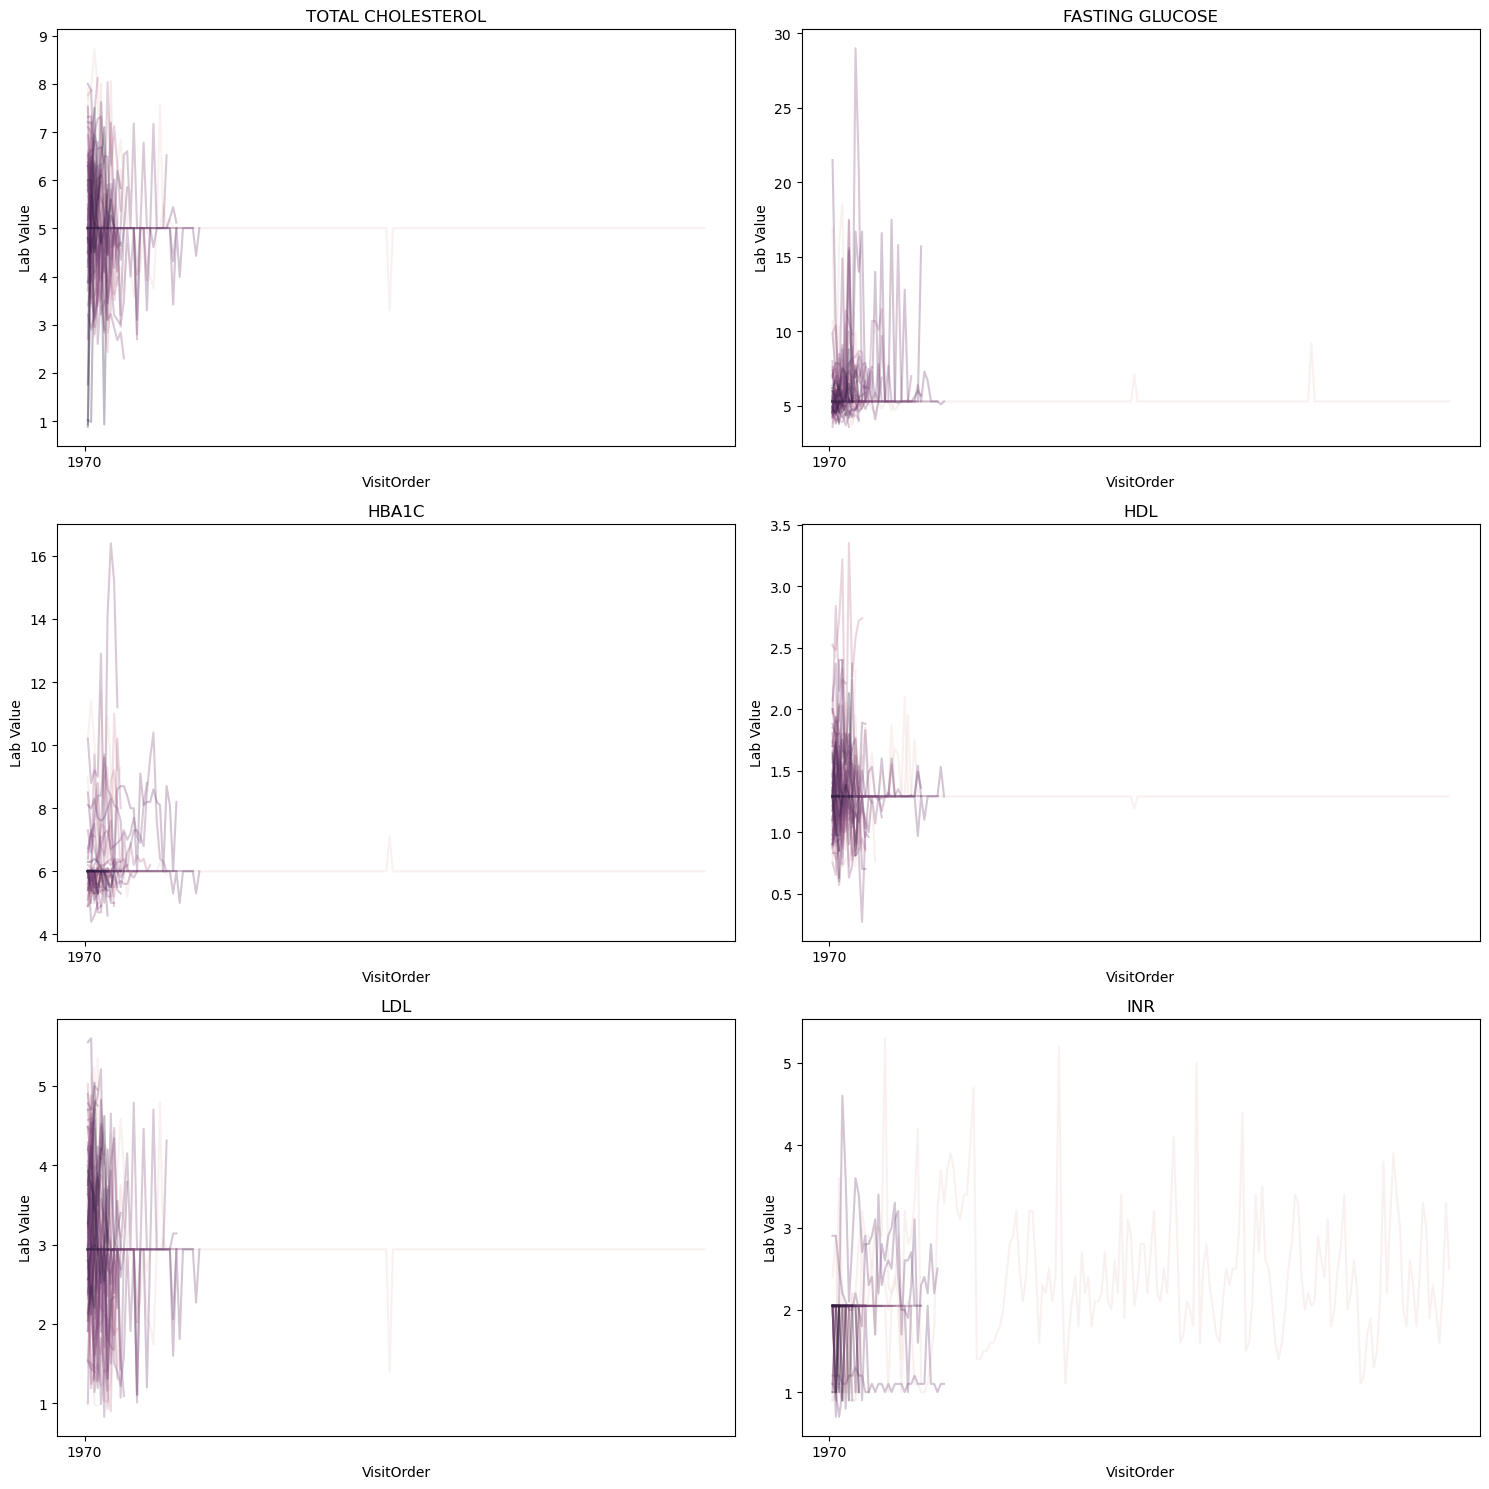

In [6]:
em.plot_trends(
    data=df,
    variables=['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C', 
            'HDL', 'LDL', 'INR'],
    date='VisitOrder',
    hue='Patient_ID',
    xlabel='VisitOrder',
    ylabel='Lab Value'
)

## We observe that most individuals have up to 25 visits. Therefore, by focusing on data from the first 25 visits, we can gain more insight into the characteristics of their lab test results.

/Users/ervinwu/Documents/CHL8010/CPCSSN-Group-Project/functions/eda_model.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[date] = pd.to_datetime(data[date])


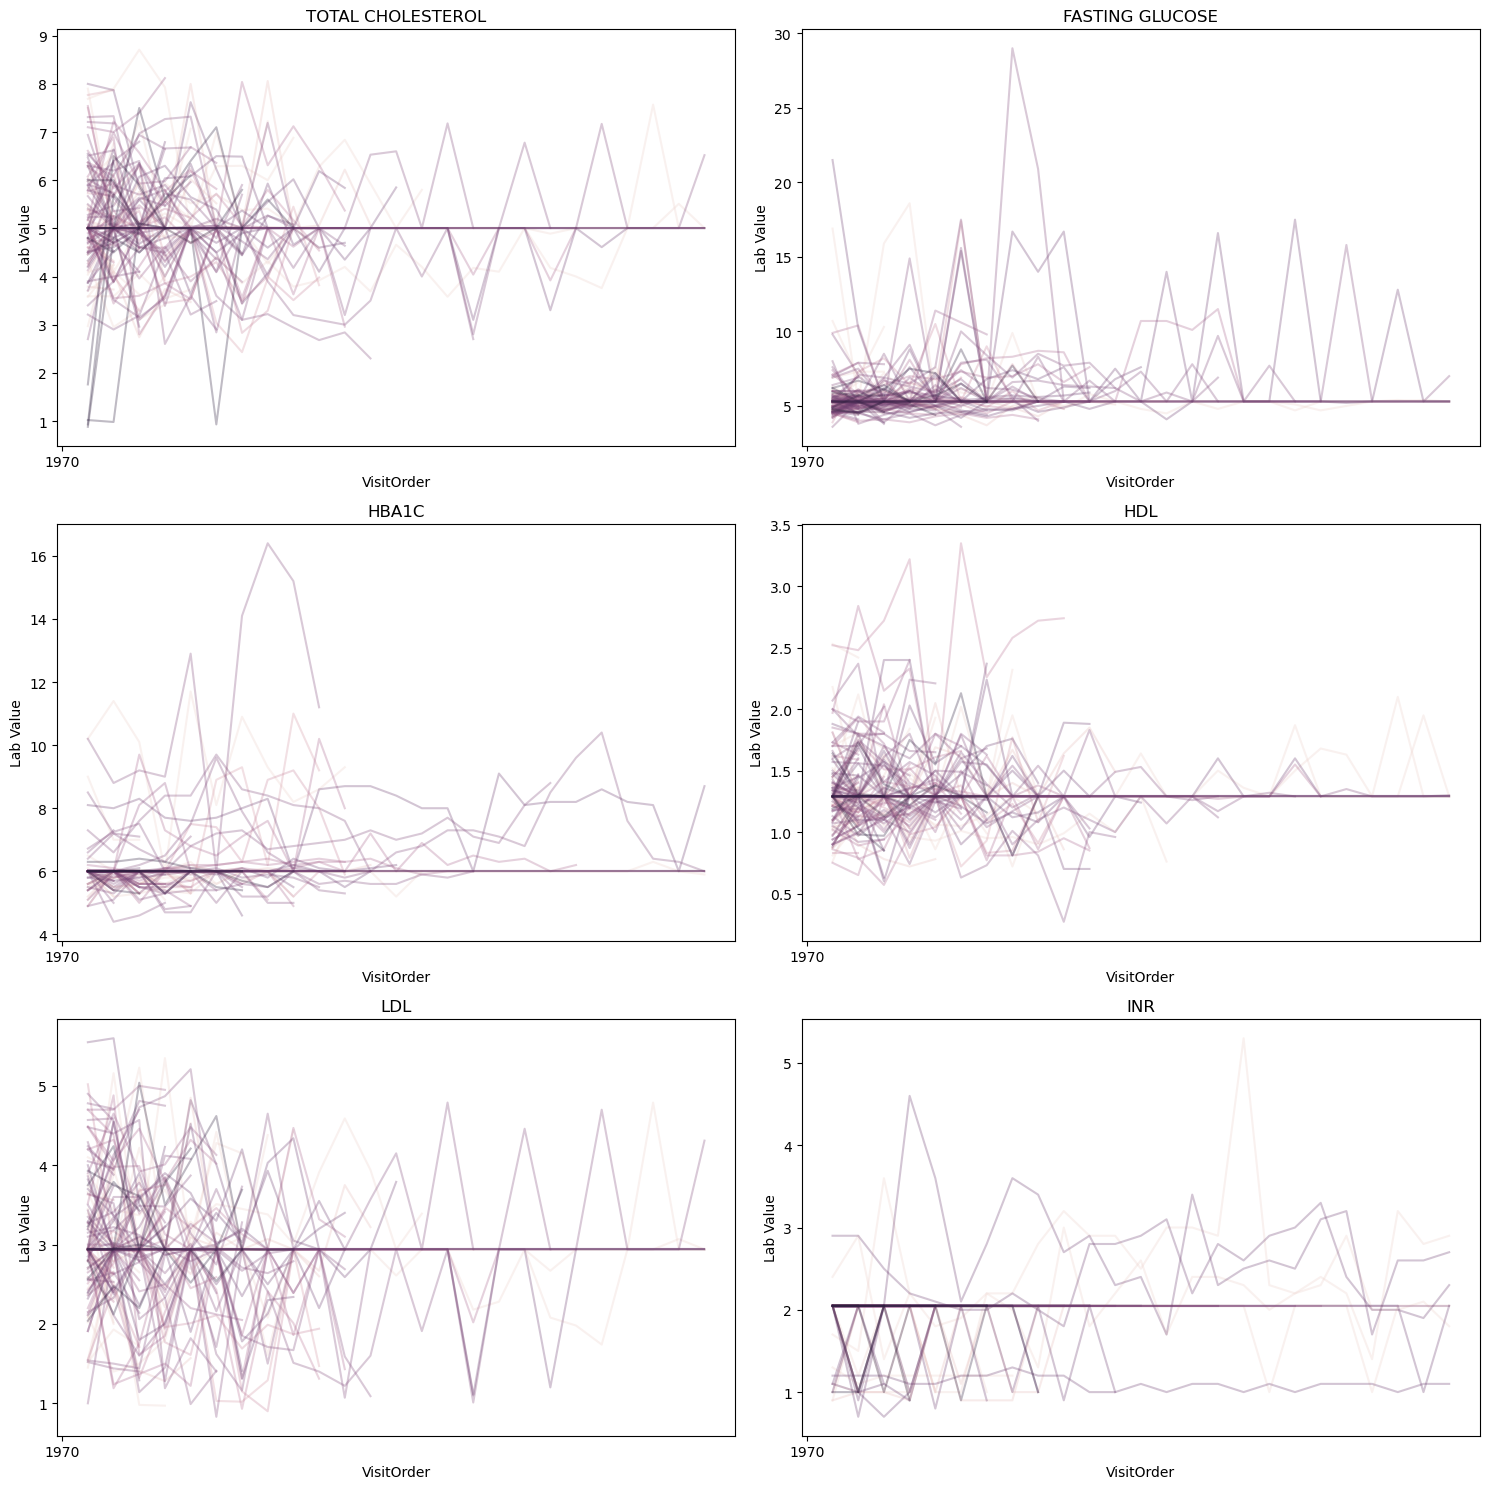

In [7]:
# keep first 25 visits
df['VisitOrder'] = pd.to_numeric(df['VisitOrder'], errors='coerce')
df_25 = df[df['VisitOrder'] <= 25]
em.plot_trends(
    data=df_25,
    variables=['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C', 
            'HDL', 'LDL', 'INR'],
    date='VisitOrder',
    hue='Patient_ID',
    xlabel='VisitOrder',
    ylabel='Lab Value'
)

In [8]:
lab_vars = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR', 'GLUCOSE TOLERANCE']

corr_matrix = df[lab_vars].corr()

print(corr_matrix)


                   TOTAL CHOLESTEROL  FASTING GLUCOSE     HBA1C       HDL  \
TOTAL CHOLESTEROL           1.000000        -0.100386 -0.060998  0.221031   
FASTING GLUCOSE            -0.100386         1.000000  0.469990 -0.115067   
HBA1C                      -0.060998         0.469990  1.000000 -0.102184   
HDL                         0.221031        -0.115067 -0.102184  1.000000   
LDL                         0.795701        -0.142196 -0.100177  0.045605   
INR                         0.009843        -0.003956  0.010934 -0.000074   
GLUCOSE TOLERANCE                NaN              NaN       NaN       NaN   

                        LDL       INR  GLUCOSE TOLERANCE  
TOTAL CHOLESTEROL  0.795701  0.009843                NaN  
FASTING GLUCOSE   -0.142196 -0.003956                NaN  
HBA1C             -0.100177  0.010934                NaN  
HDL                0.045605 -0.000074                NaN  
LDL                1.000000  0.017112                NaN  
INR                0.017112  

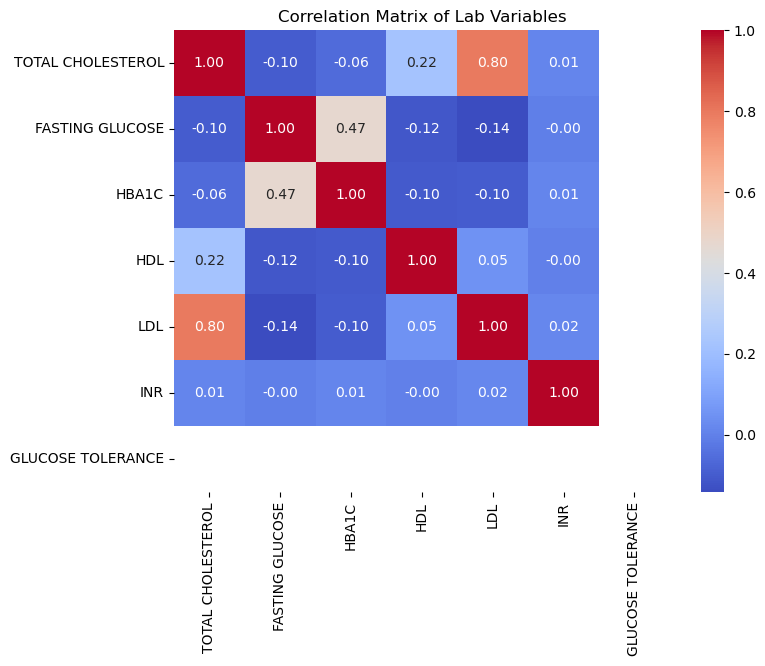

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Lab Variables')
plt.show()

## To be specific, bipolar disorder has various subtypes, so we examine the lab test results corresponding to each subtype. There are seven subtypes of bipolar disorder, which are described below.

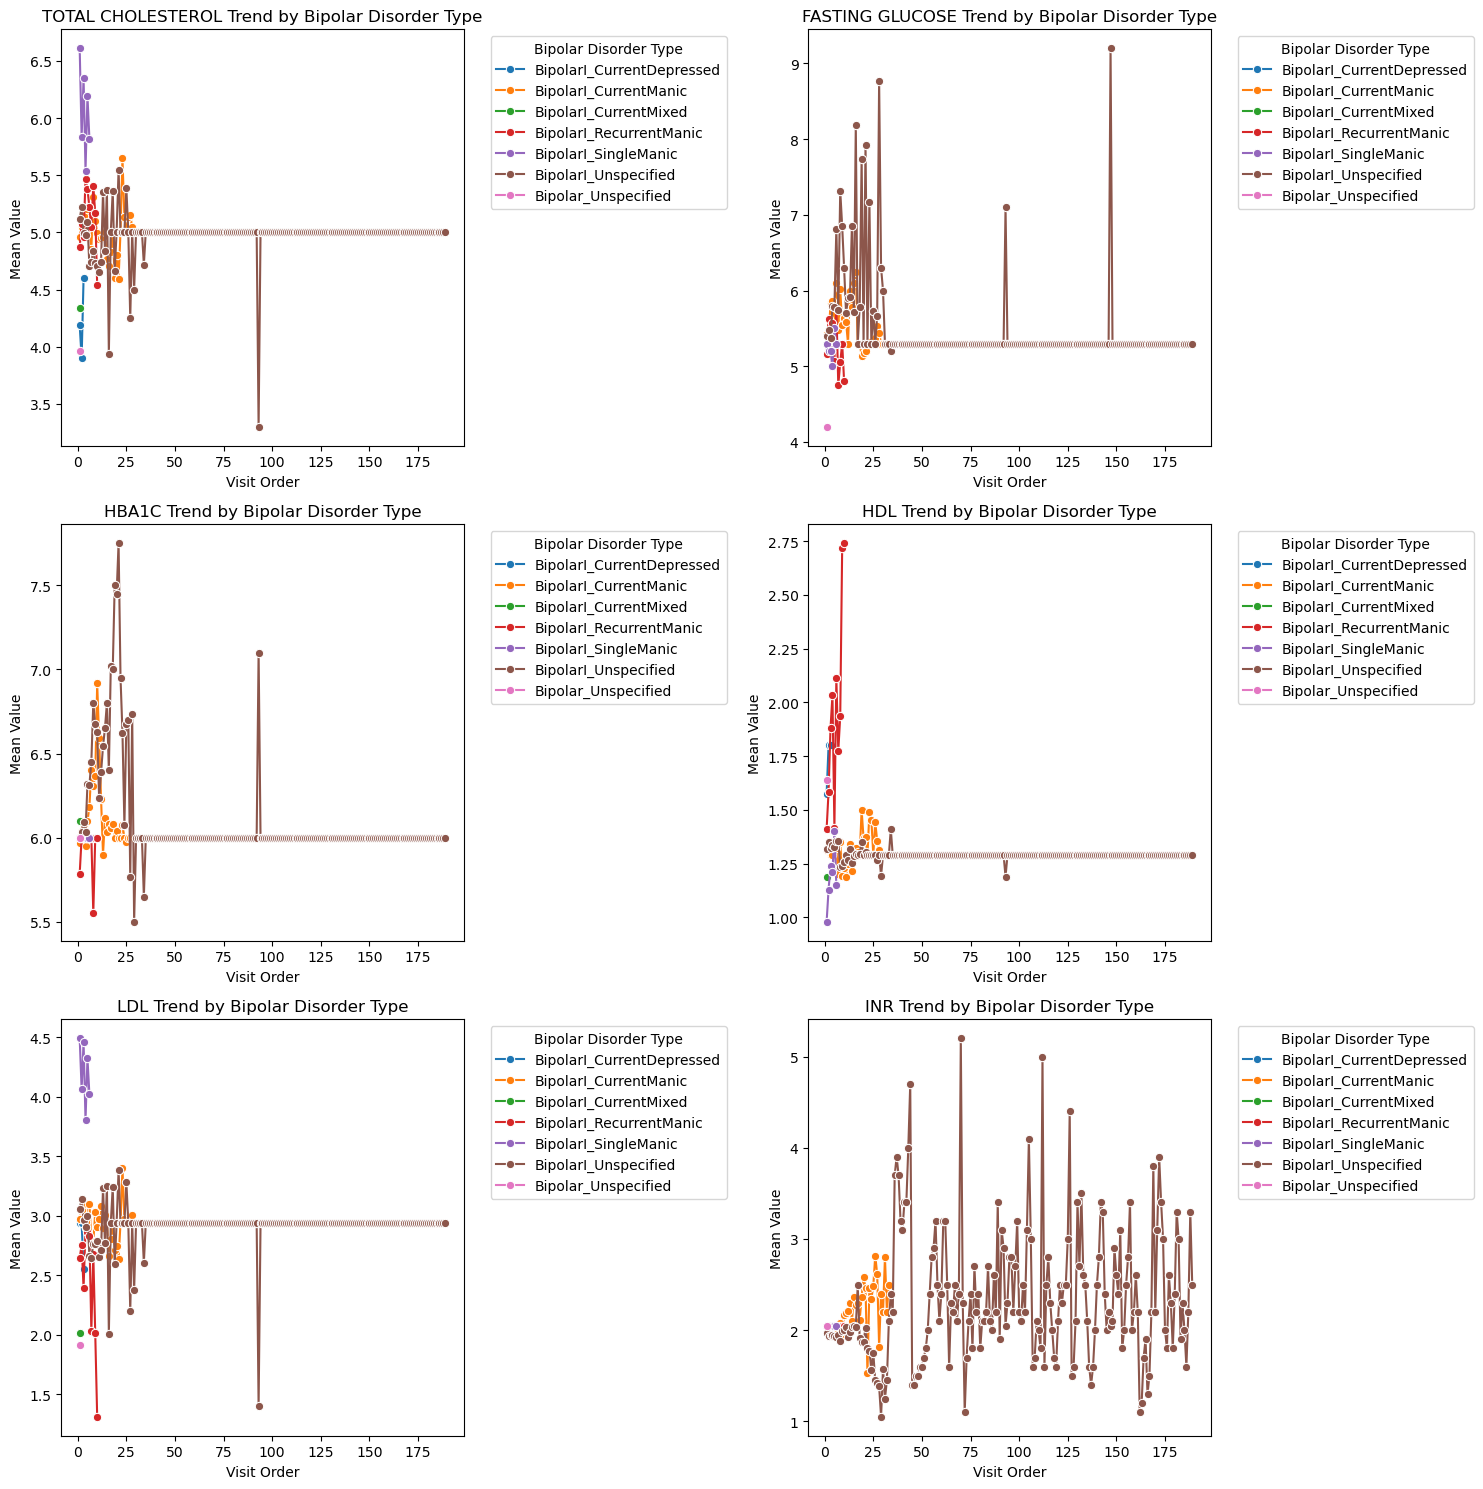

In [10]:
# Map and encode subtypes of bipolar disorders
bipolar_map = {
    '296.0': 'BipolarI_SingleManic',
    '296.1': 'BipolarI_RecurrentManic',
    '296.4': 'BipolarI_CurrentManic',
    '296.5': 'BipolarI_CurrentDepressed',
    '296.6': 'BipolarI_CurrentMixed',
    '296.7': 'BipolarI_Unspecified',
    '296.8': 'Bipolar_Unspecified'
}

bipolar_order = [
    'BipolarI_SingleManic',
    'BipolarI_RecurrentManic',
    'BipolarI_CurrentManic',
    'BipolarI_CurrentDepressed',
    'BipolarI_CurrentMixed',
    'BipolarI_Unspecified',
    'Bipolar_Unspecified'
]

df = em.map_encode(
    data=df,
    code='BD_Code',
    mapping_dict=bipolar_map,
    ordered_levels=bipolar_order,
    new_label='Bipolar Disorder Type',
    new_factor='Bipolar Disorder Type Factor',
    new_num='Bipolar Disorder Type Num'
)

# Visualize grouped trajctory of subtypes of bipolar disorders
em.plot_grouped_trends(
    data=df,
    variables=['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C', 
            'HDL', 'LDL', 'INR'],
    group_x='VisitOrder',
    group_hue='Bipolar Disorder Type',
    xlabel='Visit Order',
    ylabel='Mean Value',
    title_prefix='',
)

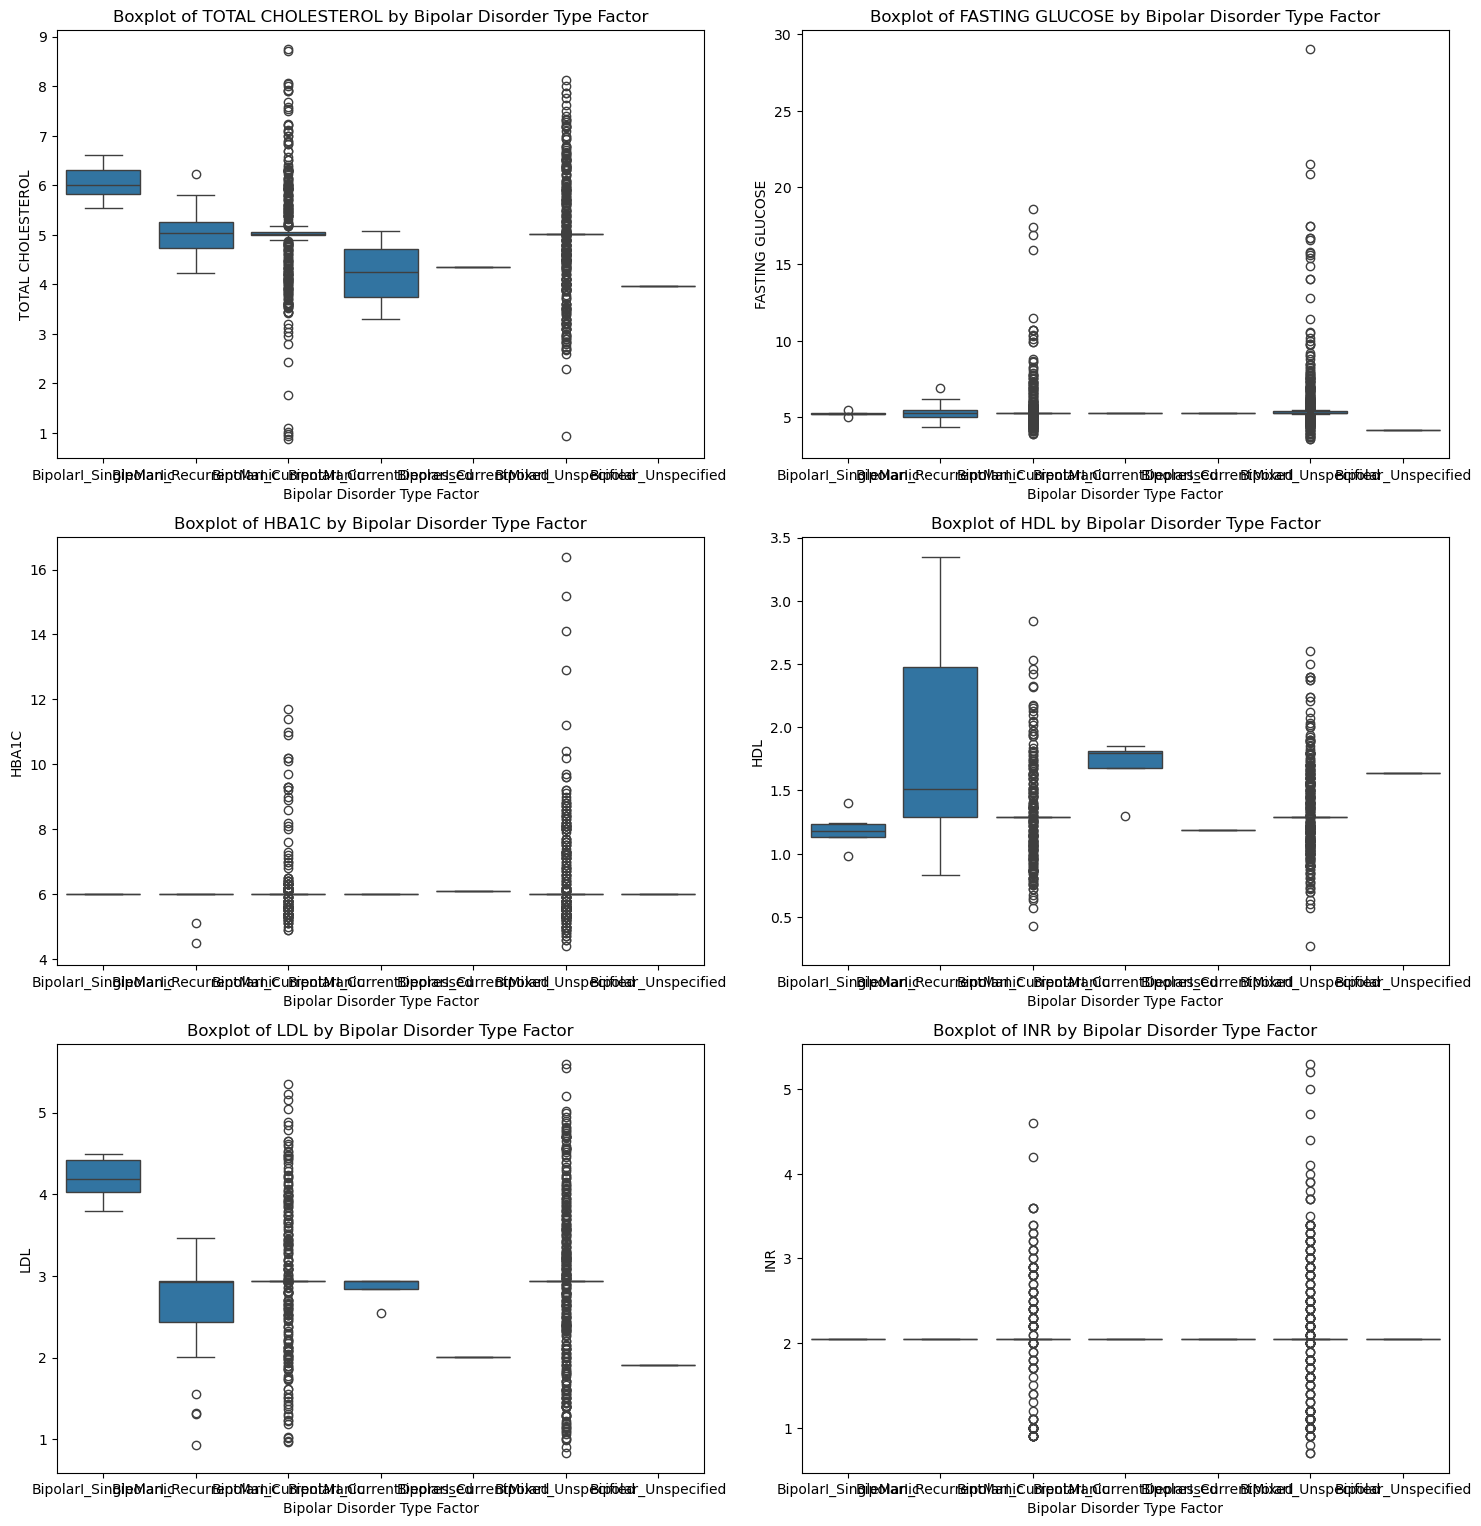

In [11]:
em.plot_grouped_boxplots(df, 
                      variables = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR'], 
                      group='Bipolar Disorder Type Factor')

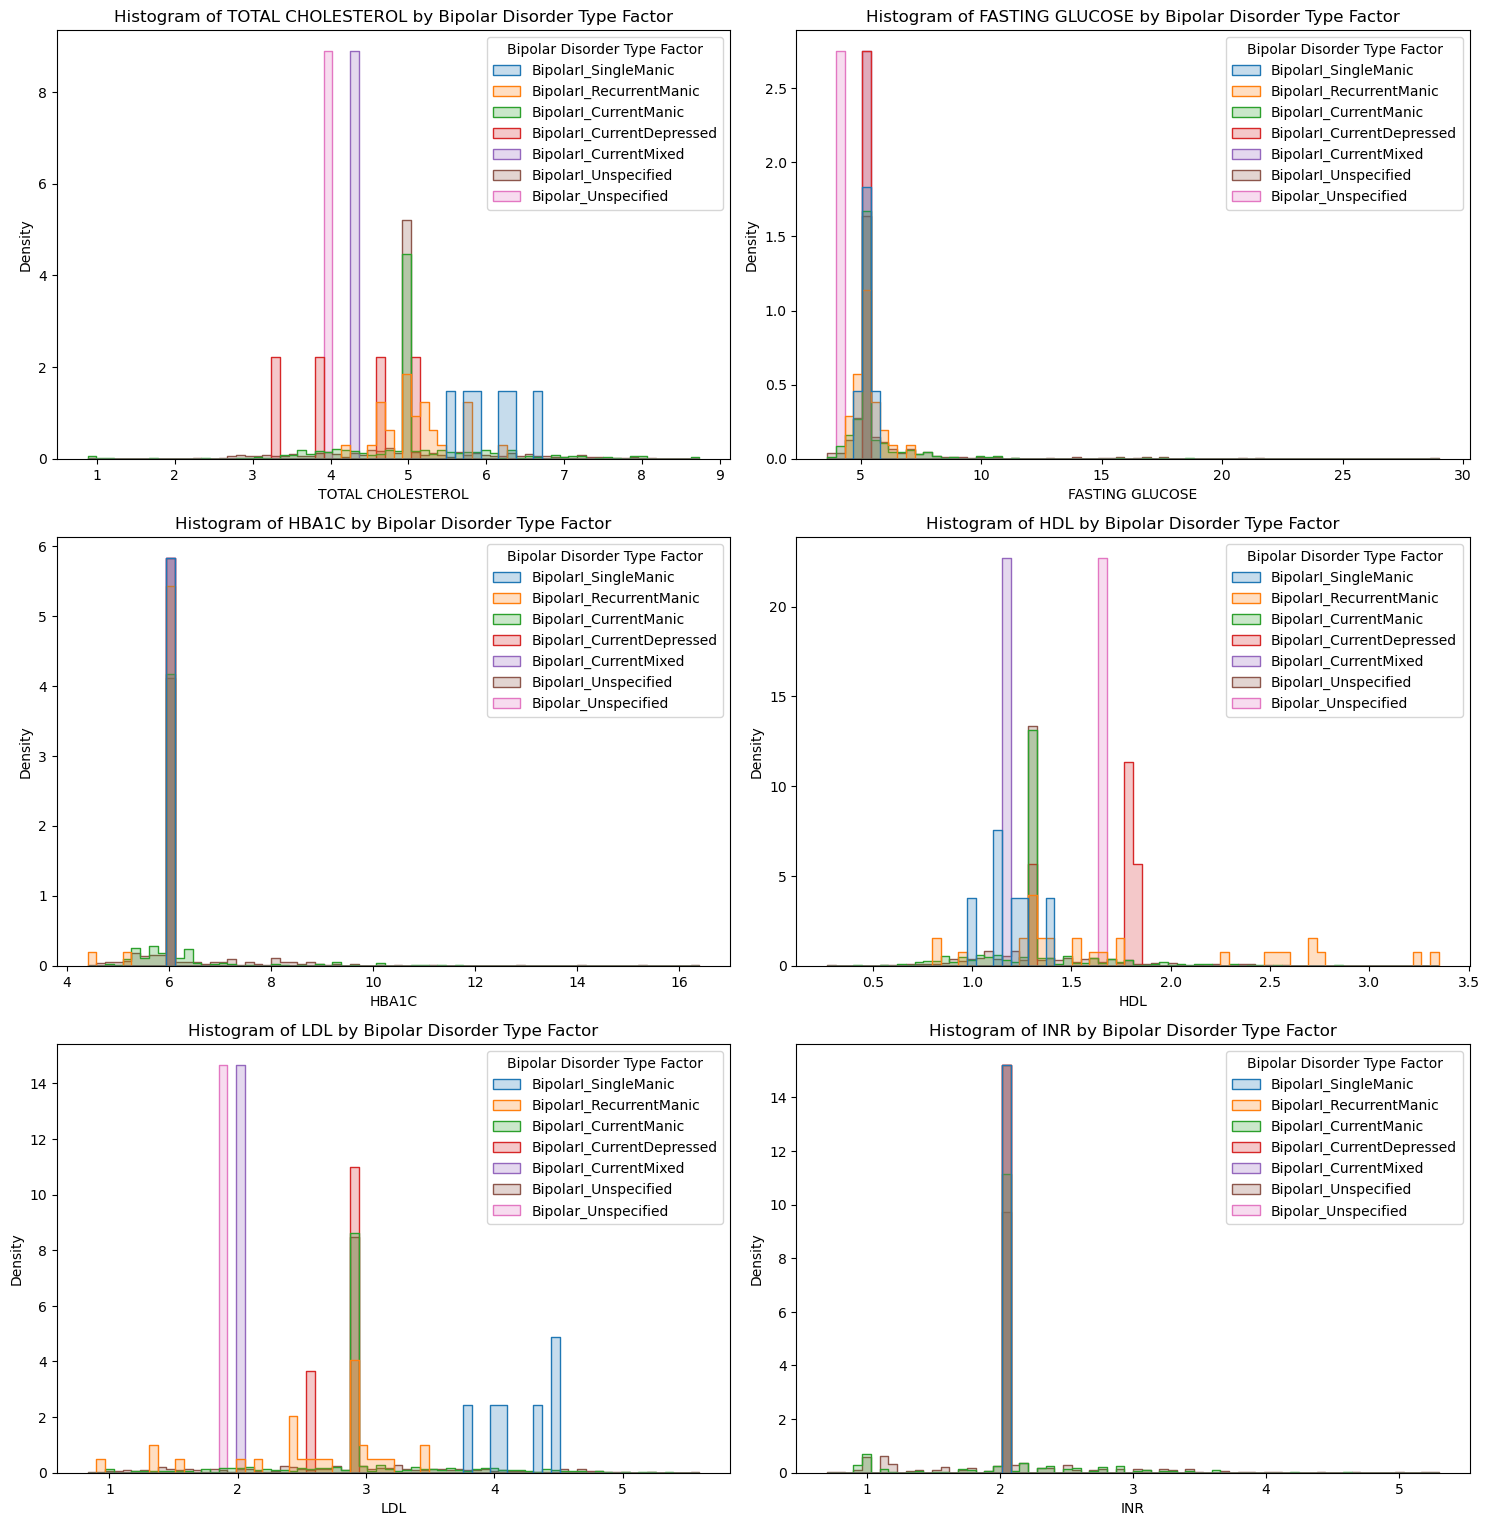

In [12]:
em.plot_grouped_histograms(df, 
                      variables = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR'], 
                      group='Bipolar Disorder Type Factor')

## Based on a literature review, we found that bipolar disorder can be categorized into three states: manic, depressed, and calm. Therefore, we recategorized the original seven statuses into these three groups.

/Users/ervinwu/Documents/CHL8010/CPCSSN-Group-Project/functions/eda_model.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = data.groupby([group_hue, group_x])[var].mean().reset_index()
/Users/ervinwu/Documents/CHL8010/CPCSSN-Group-Project/functions/eda_model.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = data.groupby([group_hue, group_x])[var].mean().reset_index()
/Users/ervinwu/Documents/CHL8010/CPCSSN-Group-Project/functions/eda_model.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False t

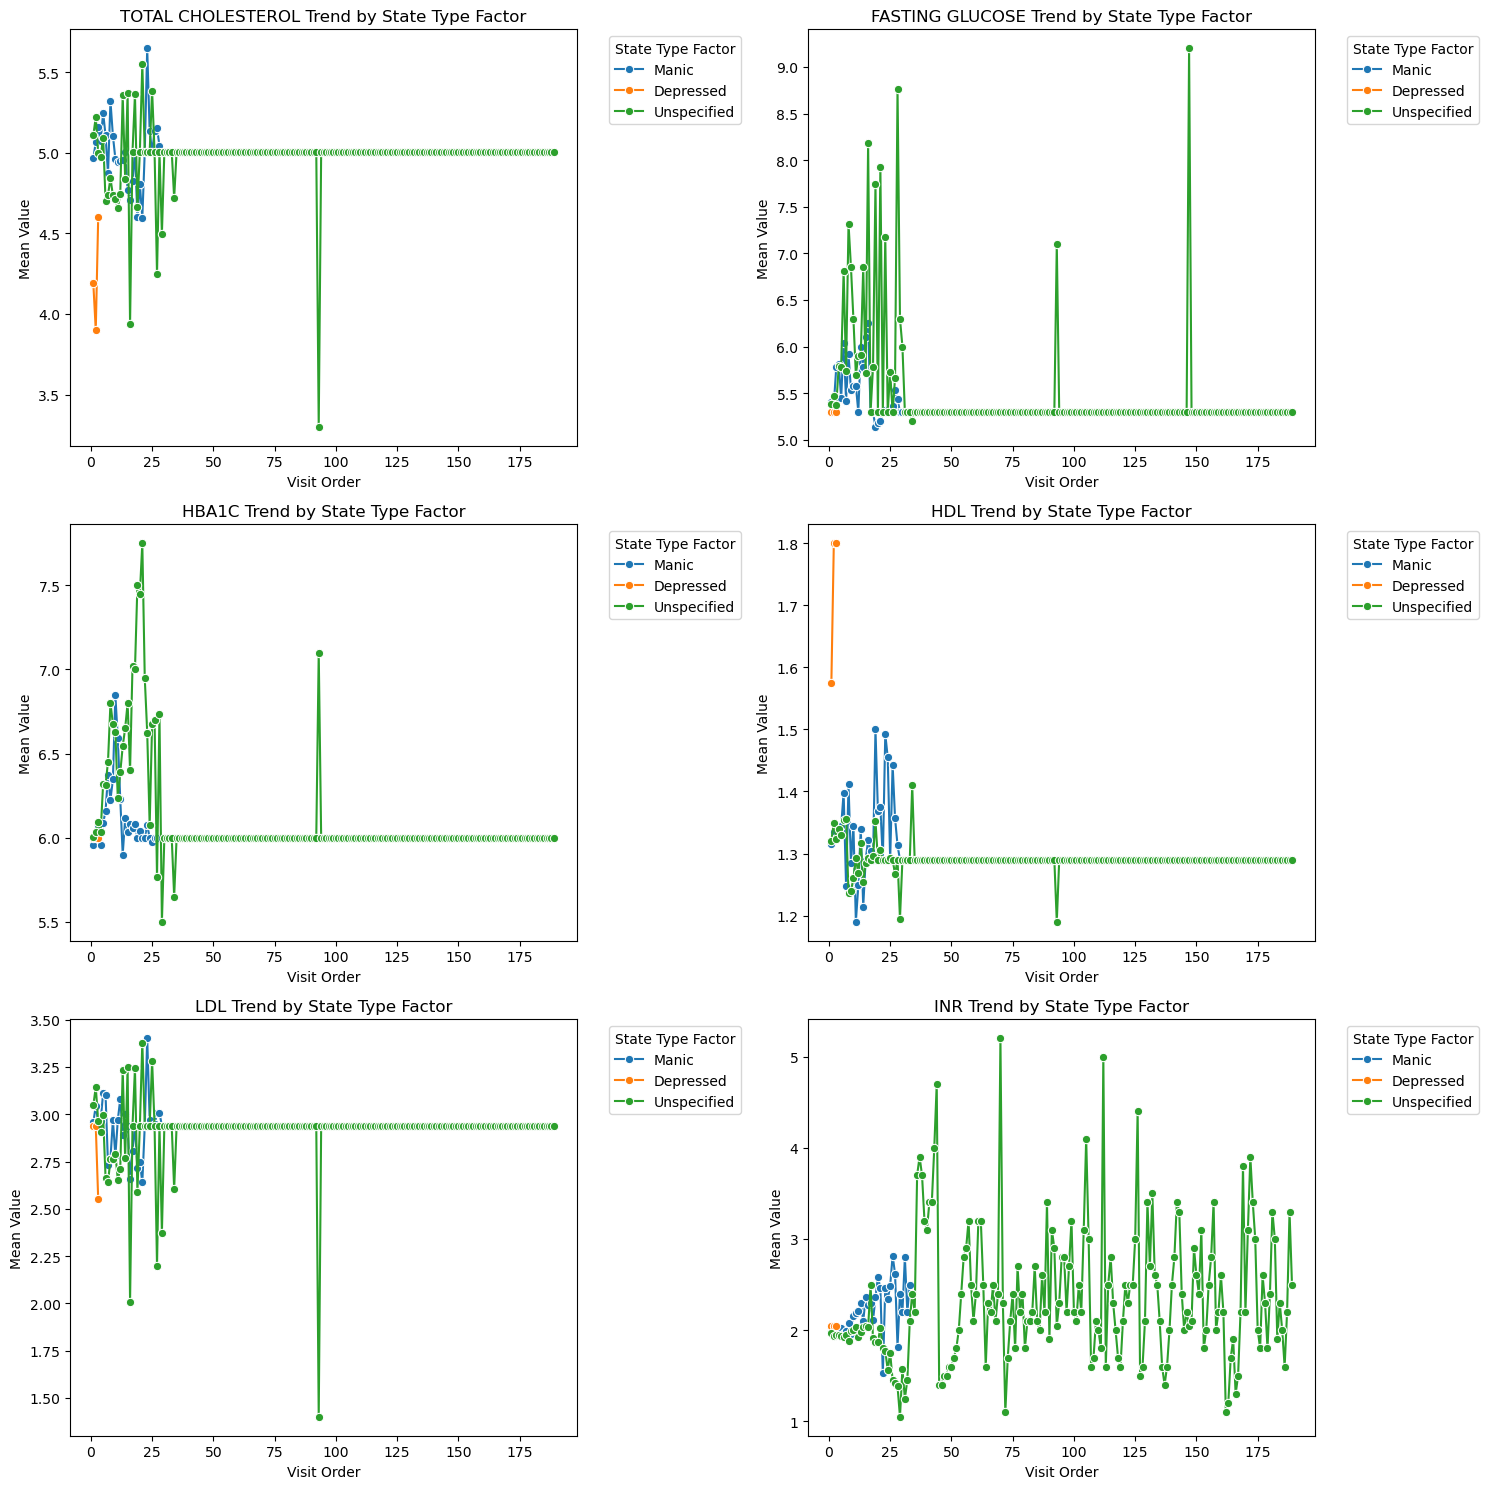

In [13]:
# mapping & encode states of bipolar disorders
state_map = {
    '296.0': 'Manic',         # BipolarI_SingleManic
    '296.1': 'Manic',         # BipolarI_RecurrentManic
    '296.4': 'Manic',         # BipolarI_CurrentManic
    '296.5': 'Depressed',     # BipolarI_CurrentDepressed
    '296.6': 'Manic',         # BipolarI_CurrentMixed (assigned to Manic, can adjust if needed)
    '296.7': 'Unspecified',   # BipolarI_Unspecified
    '296.8': 'Unspecified'    # Bipolar_Unspecified
}

state_order = ['Manic', 'Depressed', 'Unspecified']

df = em.map_encode(
    data=df,
    code='BD_Code',
    mapping_dict=state_map,
    ordered_levels=state_order,
    new_label='State Type',
    new_factor='State Type Factor',
    new_num='State Type Num'
)
# visualize states of bipolar disorder
em.plot_grouped_trends(
    data=df,
    variables=['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C', 
            'HDL', 'LDL', 'INR'],
    group_x='VisitOrder',
    group_hue='State Type Factor',
    xlabel='Visit Order',
    ylabel='Mean Value',
    title_prefix='',
)

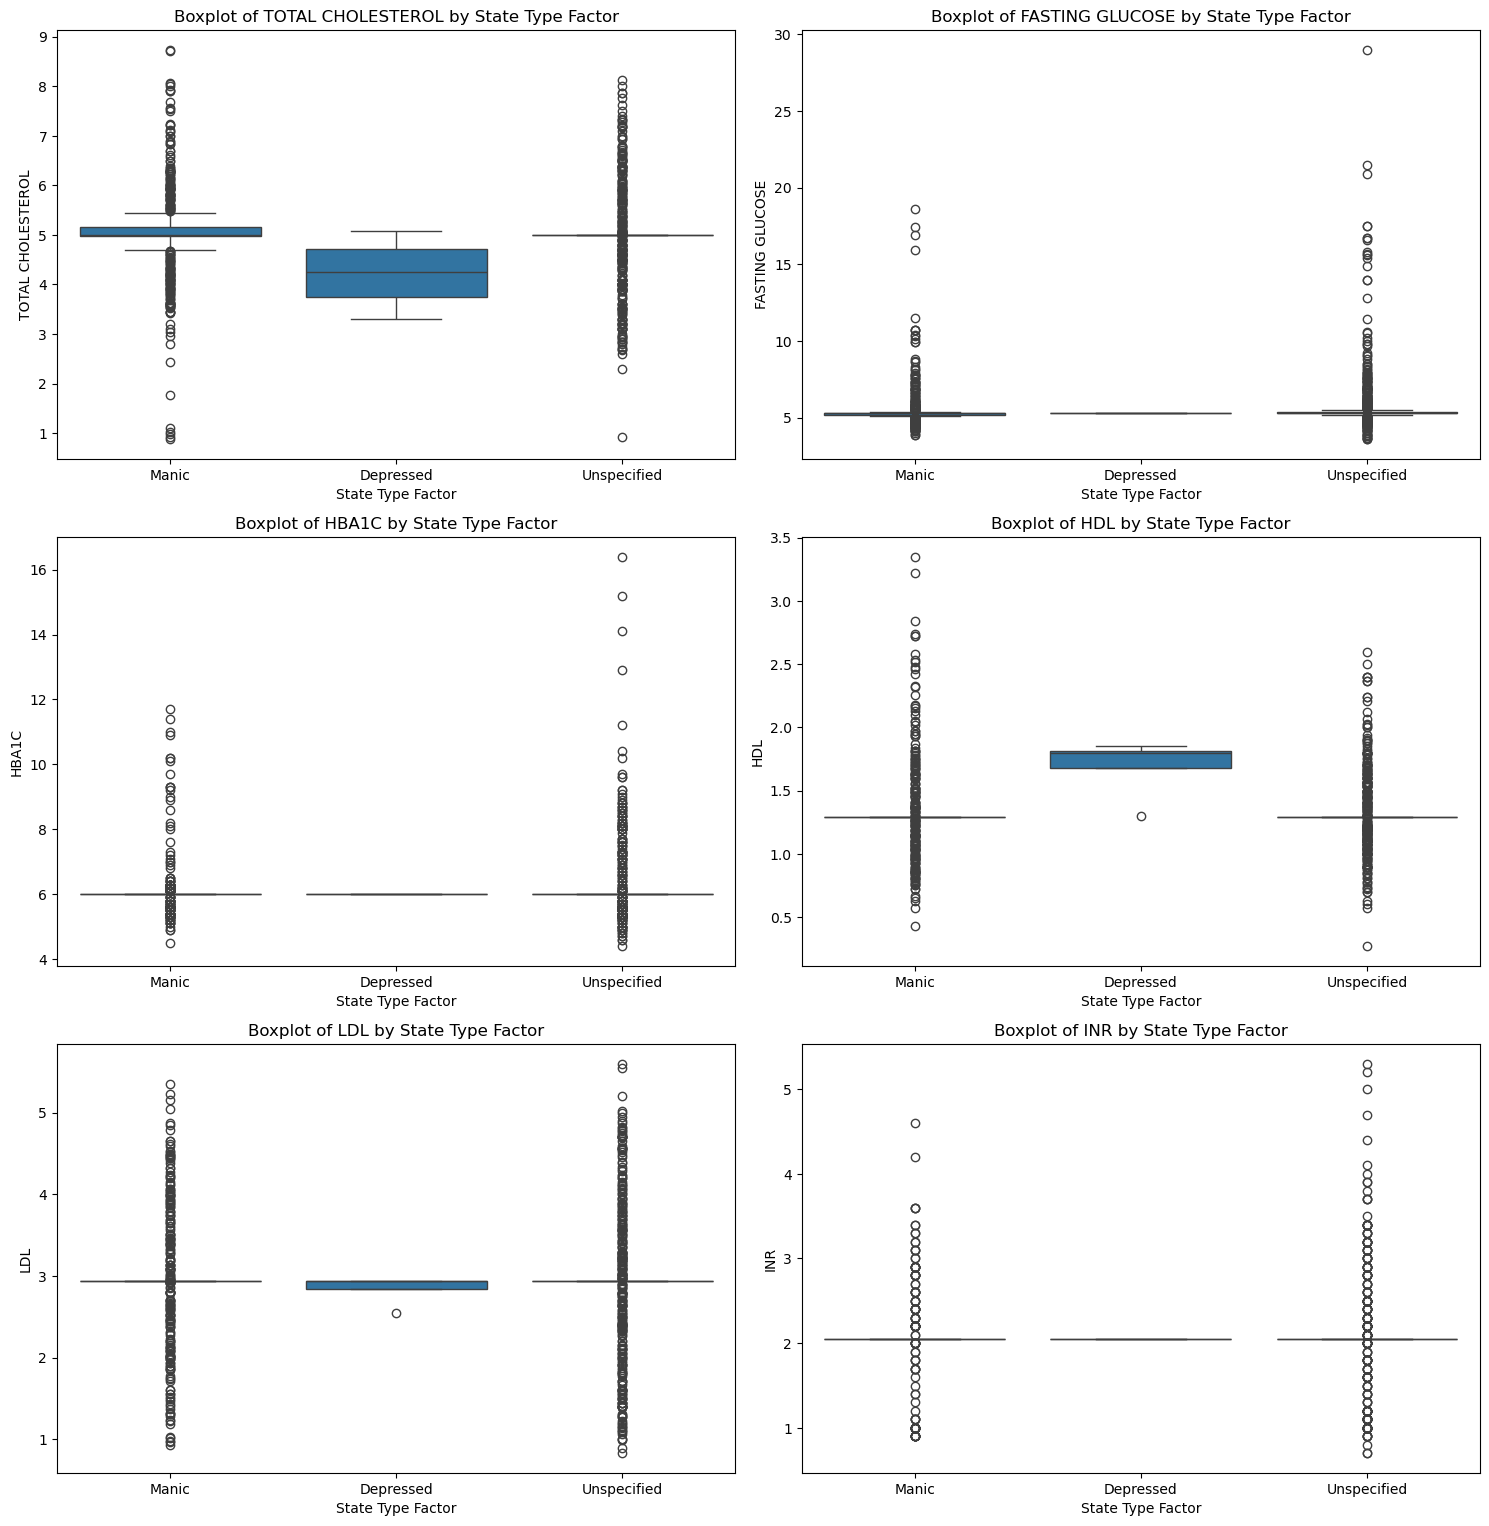

In [14]:
em.plot_grouped_boxplots(df, 
                      variables = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR'], 
                      group='State Type Factor')

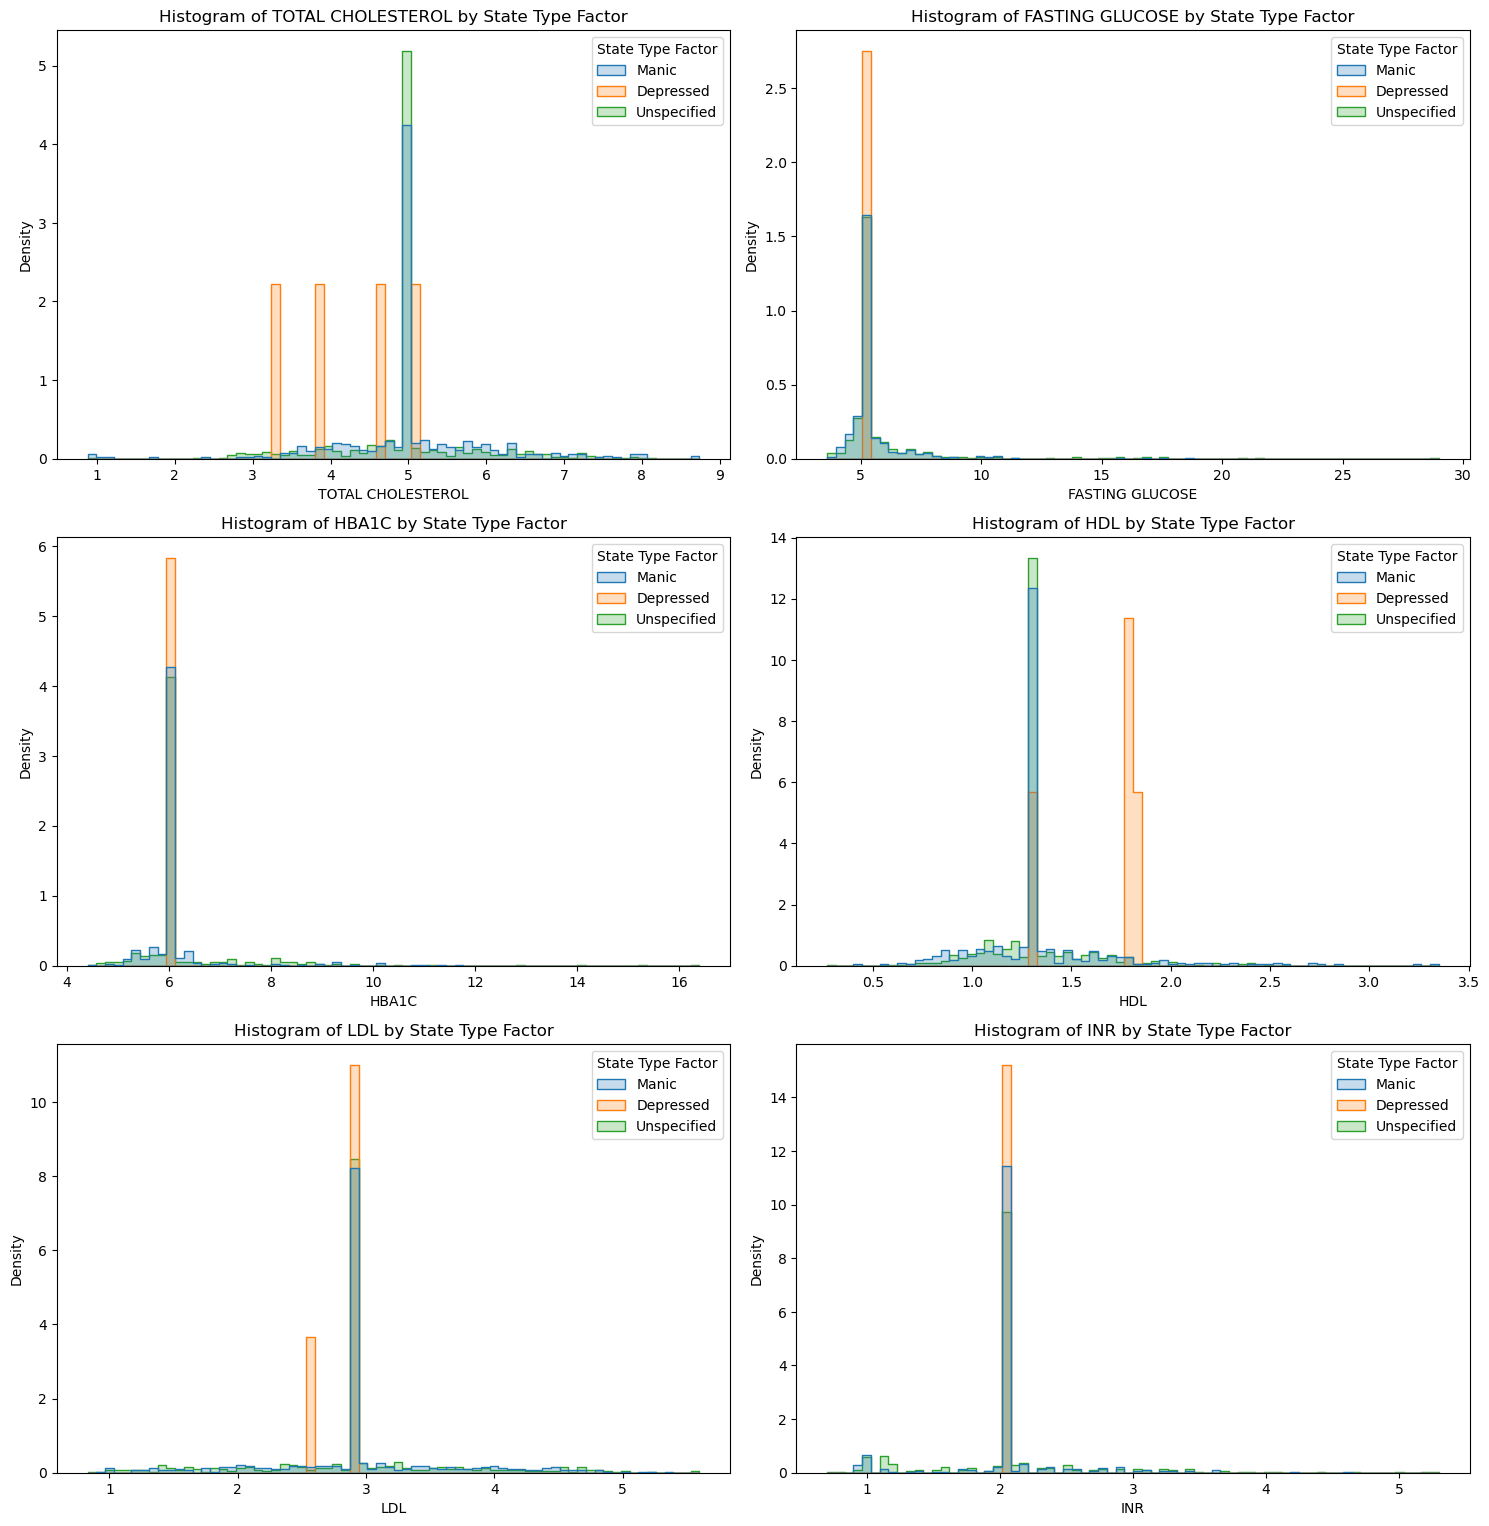

In [15]:
em.plot_grouped_histograms(df, 
                      variables = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR'], 
                      group='State Type Factor')

## Perform the Kruskal-Wallis non-parametric test for each laboratory indicator to determine whether there are significant differences in the distributions of the indicators among different subtypes.

In [16]:
# Kruskal-Wallis Test to see whether there are significant differences in the variable across multiple State_factor groups.
em.kruskal_test(df, 
             variables= ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR'], 
             group_col='Bipolar Disorder Type Factor')

TOTAL CHOLESTEROL: H=20.071, p=0.0005
FASTING GLUCOSE: H=4.750, p=0.1911
HBA1C: H=1.793, p=0.4079
HDL: H=34.036, p=0.0000
LDL: H=24.916, p=0.0001
INR: H=0.344, p=0.5573


/Users/ervinwu/Documents/CHL8010/CPCSSN-Group-Project/functions/eda_model.py:146: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_counts = df_var.groupby(group_col)[var].count()


,variable,n_groups,H_stat,p_value
0,TOTAL CHOLESTEROL,5,20.071203,4.834923e-04
1,FASTING GLUCOSE,4,4.749607,1.910775e-01
2,HBA1C,3,1.793431,4.079071e-01
3,HDL,5,34.036040,7.326133e-07
4,LDL,5,24.916176,5.230034e-05
5,INR,2,0.344360,5.573230e-01


In [17]:
em.kruskal_test(df, 
             variables= ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR'], 
             group_col='State Type Factor')

TOTAL CHOLESTEROL: H=5.496, p=0.0641
FASTING GLUCOSE: H=2.877, p=0.0899
HBA1C: H=1.301, p=0.2540
HDL: H=9.576, p=0.0083
LDL: H=0.496, p=0.7803
INR: H=0.333, p=0.5639


/Users/ervinwu/Documents/CHL8010/CPCSSN-Group-Project/functions/eda_model.py:146: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_counts = df_var.groupby(group_col)[var].count()


,variable,n_groups,H_stat,p_value
0,TOTAL CHOLESTEROL,3,5.495974,0.064057
1,FASTING GLUCOSE,2,2.876914,0.089858
2,HBA1C,2,1.301389,0.253960
3,HDL,3,9.576477,0.008327
4,LDL,3,0.496148,0.780302
5,INR,2,0.333044,0.563872


## random forest to see the correlation between lab test and subtypes of bipolar disorder


 Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       141
           1       0.93      0.98      0.96       141
           2       0.62      0.64      0.63       141
           5       0.63      0.58      0.61       141

    accuracy                           0.80       564
   macro avg       0.79      0.80      0.80       564
weighted avg       0.79      0.80      0.80       564

Confusion Matrix (Raw Counts):

[[140   0   0   1]
 [  0 138   1   2]
 [  1   5  90  45]
 [  1   5  53  82]]


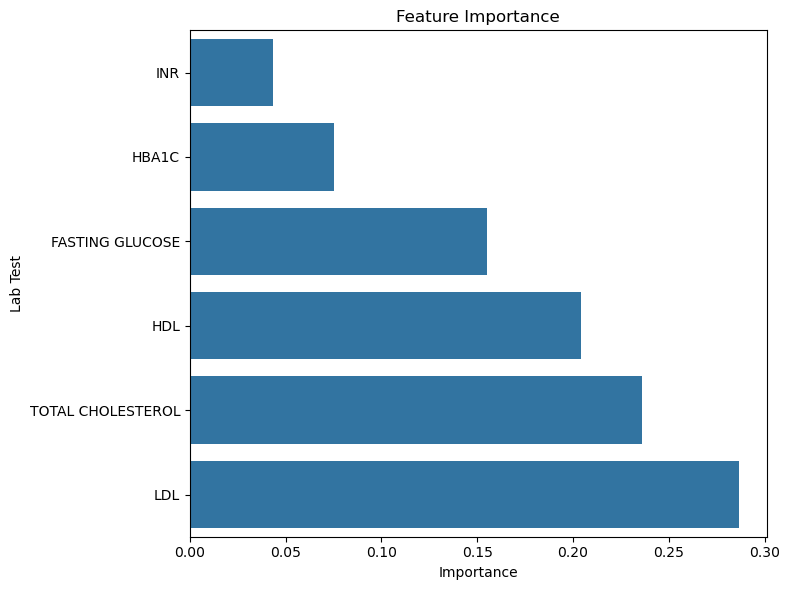


 Cross-Validated Precision: 0.758 ± 0.035


In [18]:
# Random forest

# Define lab test features 
lab_vars = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C', 'HDL', 'LDL', 'INR']
df_clean = df.dropna(subset=['Bipolar Disorder Type Factor']).copy()
df_clean['Bipolar Disorder Type Factor'] = pd.Categorical(df_clean['Bipolar Disorder Type Factor']).codes

# Keep only classes with at least 5 samples
class_counts = df_clean['Bipolar Disorder Type Factor'].value_counts()
valid_classes = class_counts[class_counts >= 5].index.tolist()
df_filtered = df_clean[df_clean['Bipolar Disorder Type Factor'].isin(valid_classes)].copy()

X = df_filtered[lab_vars]
y = df_filtered['Bipolar Disorder Type Factor'].values

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Balance class distribution using SMOTE 
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

# Split into train and test sets 
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, stratify=y_resampled, test_size=0.2, random_state=42
)

# Grid search for best hyperparameters
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid,
    scoring='precision_macro',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# Evaluate the final model
best_rf = grid_search.best_estimator_
best_rf.fit(X_train, y_train)
y_pred = best_rf.predict(X_test)

print("\n Classification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

print("Confusion Matrix (Raw Counts):\n")
print(confusion_matrix(y_test, y_pred))

# Feature importance plot 
importances = pd.Series(best_rf.feature_importances_, index=lab_vars).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Lab Test")
plt.tight_layout()
plt.show()

# Cross-validated precision
cv_scores = cross_val_score(best_rf, X_resampled, y_resampled, cv=5, scoring='precision_macro')
print(f"\n Cross-Validated Precision: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")